In [92]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE
from sklearn.neural_network import MLPRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set(style="whitegrid")

In [93]:
df = pd.read_csv("/content/drive/MyDrive/AIAssignment/Lifestyle and Wellbeing Data.csv")

df.head()

,Timestamp,FRUITS_VEGGIES,DAILY_STRESS,PLACES_VISITED,CORE_CIRCLE,SUPPORTING_OTHERS,SOCIAL_NETWORK,ACHIEVEMENT,DONATION,BMI_RANGE,...,SLEEP_HOURS,LOST_VACATION,DAILY_SHOUTING,SUFFICIENT_INCOME,PERSONAL_AWARDS,TIME_FOR_PASSION,WEEKLY_MEDITATION,AGE,GENDER,WORK_LIFE_BALANCE_SCORE
0,2007-07-15,3,2,2,5,0,5,2,0,1,...,7,5,5,1,4,0,5,36 to 50,Female,609.5
1,2007-07-15,2,3,4,3,8,10,5,2,2,...,8,2,2,2,3,2,6,36 to 50,Female,655.6
2,2007-07-15,2,3,3,4,4,10,3,2,2,...,8,10,2,2,4,8,3,36 to 50,Female,631.6
3,2007-07-15,3,3,10,3,10,7,2,5,2,...,5,7,5,1,5,2,0,51 or more,Female,622.7
4,2007-07-15,5,1,3,3,10,4,2,4,2,...,7,0,0,2,8,1,5,51 or more,Female,663.9


In [94]:
print(df.shape)
print(df.columns)
df.info()

(15972, 24)
Index(['Timestamp', 'FRUITS_VEGGIES', 'DAILY_STRESS', 'PLACES_VISITED',
       'CORE_CIRCLE', 'SUPPORTING_OTHERS', 'SOCIAL_NETWORK', 'ACHIEVEMENT',
       'DONATION', 'BMI_RANGE', 'TODO_COMPLETED', 'FLOW', 'DAILY_STEPS',
       'LIVE_VISION', 'SLEEP_HOURS', 'LOST_VACATION', 'DAILY_SHOUTING',
       'SUFFICIENT_INCOME', 'PERSONAL_AWARDS', 'TIME_FOR_PASSION',
       'WEEKLY_MEDITATION', 'AGE', 'GENDER', 'WORK_LIFE_BALANCE_SCORE'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15972 entries, 0 to 15971
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Timestamp                15972 non-null  object 
 1   FRUITS_VEGGIES           15972 non-null  int64  
 2   DAILY_STRESS             15972 non-null  object 
 3   PLACES_VISITED           15972 non-null  int64  
 4   CORE_CIRCLE              15972 non-null  int64  
 5   SUPPORTING_OTHERS        15972 non-null  

In [95]:
features = [
    "SLEEP_HOURS",
    "DAILY_STRESS",
    "DAILY_STEPS",
    "BMI_RANGE",
    "TIME_FOR_PASSION"
]

target = "WORK_LIFE_BALANCE_SCORE"

data = df[features + [target]]
data.head()

,SLEEP_HOURS,DAILY_STRESS,DAILY_STEPS,BMI_RANGE,TIME_FOR_PASSION,WORK_LIFE_BALANCE_SCORE
0,7,2,5,1,0,609.5
1,8,3,5,2,2,655.6
2,8,3,4,2,8,631.6
3,5,3,5,2,2,622.7
4,7,1,5,2,1,663.9


In [96]:
data.isnull().sum()

,0
SLEEP_HOURS,0
DAILY_STRESS,0
DAILY_STEPS,0
BMI_RANGE,0
TIME_FOR_PASSION,0
WORK_LIFE_BALANCE_SCORE,0


In [97]:
data.describe()

,SLEEP_HOURS,DAILY_STEPS,BMI_RANGE,TIME_FOR_PASSION,WORK_LIFE_BALANCE_SCORE
count,15972.000000,15972.000000,15972.000000,15972.000000,15972.000000
mean,7.042888,5.703606,1.410656,3.326572,666.751503
std,1.199044,2.891013,0.491968,2.729293,45.019868
min,1.000000,1.000000,1.000000,0.000000,480.000000
25%,6.000000,3.000000,1.000000,1.000000,636.000000
50%,7.000000,5.000000,1.000000,3.000000,667.700000
75%,8.000000,8.000000,2.000000,5.000000,698.500000
max,10.000000,10.000000,2.000000,10.000000,820.200000


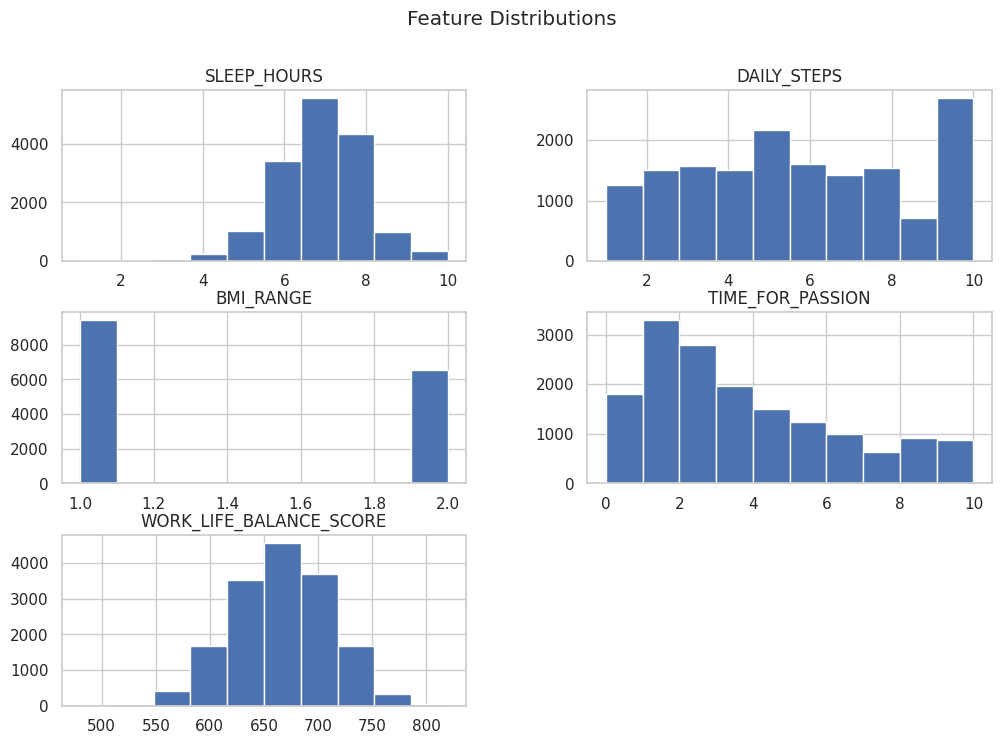

In [98]:
data.hist(figsize=(12,8))
plt.suptitle("Feature Distributions")
plt.show()

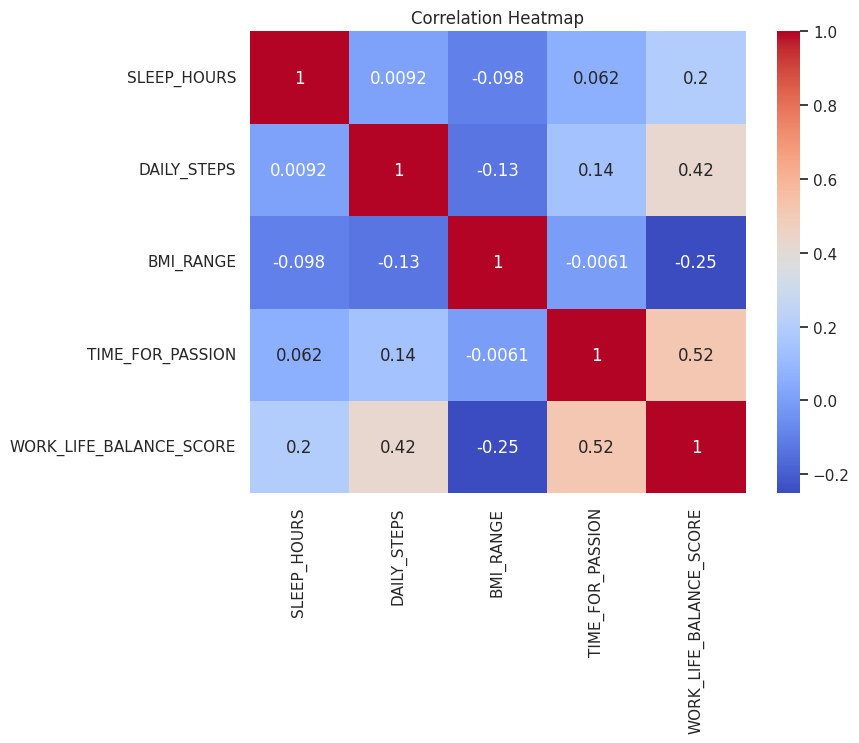

In [99]:
plt.figure(figsize=(8,6))

numeric_data = data.select_dtypes(include=["int64", "float64"])
sns.heatmap(numeric_data.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

In [100]:
X = data[features].select_dtypes(include=["int64", "float64"])
y = data[target]

In [101]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [102]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [103]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Linear Regression Results")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2:", r2_score(y_test, y_pred_lr))

Linear Regression Results
MAE: 26.49787686314621
RMSE: 32.793024430036816
R2: 0.45869277260868757


In [104]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Results")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2:", r2_score(y_test, y_pred_rf))

Random Forest Results
MAE: 26.533426041242198
RMSE: 33.12444652784492
R2: 0.44769605990283


In [105]:
param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [None, 10, 20]
}

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring="r2"
)

grid_rf.fit(X_train, y_train)

print("Best Parameters:", grid_rf.best_params_)
print("Best CV Score:", grid_rf.best_score_)

Best Parameters: {'max_depth': 10, 'n_estimators': 100}
Best CV Score: 0.44426158220493406


In [106]:
rfe = RFE(LinearRegression(), n_features_to_select=3)
rfe.fit(X_train_scaled, y_train)

selected_features = np.array(X.columns)[rfe.support_]
selected_features

array(['DAILY_STEPS', 'BMI_RANGE', 'TIME_FOR_PASSION'], dtype=object)

In [107]:
mlp = MLPRegressor(
    hidden_layer_sizes=(64,32),
    activation="relu",
    max_iter=1000,
    random_state=42
)

mlp.fit(X_train_scaled, y_train)

y_pred_mlp = mlp.predict(X_test_scaled)

print("Neural Network Regression")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_mlp)))
print("R2:", r2_score(y_test, y_pred_mlp))

Neural Network Regression
RMSE: 32.25457554423952
R2: 0.47632294831021005


In [108]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Neural Network"],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_mlp))
    ],
    "R2": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_mlp)
    ]
})

results

,Model,RMSE,R2
0,Linear Regression,32.793024,0.458693
1,Random Forest,33.124447,0.447696
2,Neural Network,32.254576,0.476323
